In [2]:
###testing R in jyupter 

In [3]:
library(purrr)
library(tidyverse)
library(edgeR)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.6     ✔ dplyr   1.0.9
✔ tibble  3.1.7     ✔ stringr 1.4.0
✔ tidyr   1.2.0     ✔ forcats 0.5.1
✔ readr   2.1.2     

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Loading required package: limma



In [4]:
lfbl=function(pattern,level=1){
    if(!exists("lof")) lof=vector("character",0)
    temp=list.files(pattern=pattern,no..=T)
    if(!is.na(temp[1])) lof=c(lof,paste0(getwd(),"/",temp))
    if(level>0){
        dirf=list.dirs(full.names=F,recursive=F)
        for(i in dirf){
            setwd(i)
            lof=c(lof,lfbl(pattern,level-1))
            setwd("..")
        }
    }
    return(lof)
}




In [5]:
setwd("/lustre/scratch123/hgi/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome")
getwd()

[1] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome"

In [6]:
f_files = lfbl(pattern = 'featureCounts$',level=2)
f_files


[1] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts"
  [2] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts"
  [3] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts"
  [4] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts"
  [5] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts"
  [6] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts"
  [7] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts"
  [8] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts"
  [9] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts"
 [10] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/A_J/A_J/A_J-12.5dpp.1.featureCounts"                        
 [11] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/A_J/A_J/A_J-12.5dpp.2.featureCounts"                        
 [12] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/A_J/A_J/A_J-12.5dpp.3.featureCounts"                        
 [13] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/A_J/A_J/A_J-16.5dpc.1.featureCounts"                        
 [14] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/A_J/A_J/A_J-16.5dpc.2.featureCounts"                        
 [15] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/A_J/A_J/A_J-16.5dpc.3.featureCounts"                        
 [16] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/A_J/A_J/A_J-20.5dpp.1.featureCounts"                        
 [17] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/A_J/A_J/A_J-20.5dpp.2.featureCounts"                        
 [18] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/A_J/A_J/A_J-20.5dpp.3.featureCounts"                        
 [19] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/AKR_J/AKR_J/AKR_J-12.5dpp.1.featureCounts"                  
 [20] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/AKR_J/AKR_J/AKR_J-12.5dpp.2.featureCounts"                  
 [21] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/AKR_J/AKR_J/AKR_J-12.5dpp.3.featureCounts"                  
 [22] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/AKR_J/AKR_J/AKR_J-16.5dpc.1.featureCo

In [7]:

groups = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
groups

[1] "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp"
  [4] "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc"
  [7] "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp"
 [10] "A_J-12.5dpp"         "A_J-12.5dpp"         "A_J-12.5dpp"        
 [13] "A_J-16.5dpc"         "A_J-16.5dpc"         "A_J-16.5dpc"        
 [16] "A_J-20.5dpp"         "A_J-20.5dpp"         "A_J-20.5dpp"        
 [19] "AKR_J-12.5dpp"       "AKR_J-12.5dpp"       "AKR_J-12.5dpp"      
 [22] "AKR_J-16.5dpc"       "AKR_J-16.5dpc"       "AKR_J-16.5dpc"      
 [25] "AKR_J-20.5dpp"       "AKR_J-20.5dpp"       "AKR_J-20.5dpp"      
 [28] "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"    
 [31] "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"    
 [34] "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"    
 [37] "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"    
 [40] "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"    
 [43] "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"    
 [46] "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"  
 [49] "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"  
 [52] "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"  
 [55] "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"   
 [58] "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"   
 [61] "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"   
 [64] "CBA_J-12.5dpp"       "CBA_J-12.5dpp"       "CBA_J-12.5dpp"      
 [67] "CBA_J-16.5dpc"       "CBA_J-16.5dpc"       "CBA_J-16.5dpc"      
 [70] "CBA_J-20.5dpp"       "CBA_J-20.5dpp"       "CBA_J-20.5dpp"      
 [73] "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"     
 [76] "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"     
 [79] "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"     
 [82] "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"     
 [85] "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"     
 [88] "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"     
 [91] "LP_J-12.5dpp"        "LP_J-12.5dpp"        "LP_J-12.5dpp"       
 [94] "LP_J-16.5dpc"        "LP_J-16.5dpc"        "LP_J-16.5dpc"       
 [97] "LP_J-20.5dpp"        "LP_J-20.5dpp"        "LP_J-20.5dpp"       
[100] "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp" 
[103] "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc" 
[106] "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp" 
[109] "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-12.5dpp"  
[112] "NZO_HlLtJ-16.5dpc"   "NZO_HlLtJ-16.5dpc"   "NZO_HlLtJ-16.5dpc"  
[115] "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"  
[118] "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"    
[121] "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"    
[124] "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"    
[127] "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"  
[130] "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"  
[133] "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"  
[136] "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"    
[139] "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"    
[142] "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"

In [8]:

#list of sample names with replicates 
lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))

lables

[1] "129S1_SvImJ-12.5dpp.1" "129S1_SvImJ-12.5dpp.2" "129S1_SvImJ-12.5dpp.3"
  [4] "129S1_SvImJ-16.5dpc.1" "129S1_SvImJ-16.5dpc.2" "129S1_SvImJ-16.5dpc.3"
  [7] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [10] "A_J-12.5dpp.1"         "A_J-12.5dpp.2"         "A_J-12.5dpp.3"        
 [13] "A_J-16.5dpc.1"         "A_J-16.5dpc.2"         "A_J-16.5dpc.3"        
 [16] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [19] "AKR_J-12.5dpp.1"       "AKR_J-12.5dpp.2"       "AKR_J-12.5dpp.3"      
 [22] "AKR_J-16.5dpc.1"       "AKR_J-16.5dpc.2"       "AKR_J-16.5dpc.3"      
 [25] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
 [28] "BALB_cJ-12.5dpp.1"     "BALB_cJ-12.5dpp.2"     "BALB_cJ-12.5dpp.3"    
 [31] "BALB_cJ-16.5dpc.1"     "BALB_cJ-16.5dpc.2"     "BALB_cJ-16.5dpc.3"    
 [34] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
 [37] "C3H_HeJ-12.5dpp.1"     "C3H_HeJ-12.5dpp.2"     "C3H_HeJ-12.5dpp.3"    
 [40] "C3H_HeJ-16.5dpc.1"     "C3H_HeJ-16.5dpc.2"     "C3H_HeJ-16.5dpc.3"    
 [43] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
 [46] "C57BL_6NJ-12.5dpp.1"   "C57BL_6NJ-12.5dpp.2"   "C57BL_6NJ-12.5dpp.3"  
 [49] "C57BL_6NJ-16.5dpc.1"   "C57BL_6NJ-16.5dpc.2"   "C57BL_6NJ-16.5dpc.3"  
 [52] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
 [55] "CAST_EiJ-12.5dpp.1"    "CAST_EiJ-12.5dpp.2"    "CAST_EiJ-12.5dpp.3"   
 [58] "CAST_EiJ-16.5dpc.1"    "CAST_EiJ-16.5dpc.2"    "CAST_EiJ-16.5dpc.3"   
 [61] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
 [64] "CBA_J-12.5dpp.1"       "CBA_J-12.5dpp.2"       "CBA_J-12.5dpp.3"      
 [67] "CBA_J-16.5dpc.1"       "CBA_J-16.5dpc.2"       "CBA_J-16.5dpc.3"      
 [70] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
 [73] "DBA_2J-12.5dpp.1"      "DBA_2J-12.5dpp.2"      "DBA_2J-12.5dpp.3"     
 [76] "DBA_2J-16.5dpc.1"      "DBA_2J-16.5dpc.2"      "DBA_2J-16.5dpc.3"     
 [79] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
 [82] "FVB_NJ-12.5dpp.1"      "FVB_NJ-12.5dpp.2"      "FVB_NJ-12.5dpp.3"     
 [85] "FVB_NJ-16.5dpc.1"      "FVB_NJ-16.5dpc.2"      "FVB_NJ-16.5dpc.3"     
 [88] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
 [91] "LP_J-12.5dpp.1"        "LP_J-12.5dpp.2"        "LP_J-12.5dpp.3"       
 [94] "LP_J-16.5dpc.1"        "LP_J-16.5dpc.2"        "LP_J-16.5dpc.3"       
 [97] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
[100] "NOD_ShiLtJ-12.5dpp.1"  "NOD_ShiLtJ-12.5dpp.2"  "NOD_ShiLtJ-12.5dpp.3" 
[103] "NOD_ShiLtJ-16.5dpc.1"  "NOD_ShiLtJ-16.5dpc.2"  "NOD_ShiLtJ-16.5dpc.3" 
[106] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[109] "NZO_HlLtJ-12.5dpp.1"   "NZO_HlLtJ-12.5dpp.2"   "NZO_HlLtJ-12.5dpp.3"  
[112] "NZO_HlLtJ-16.5dpc.1"   "NZO_HlLtJ-16.5dpc.2"   "NZO_HlLtJ-16.5dpc.3"  
[115] "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"   "NZO_HlLtJ-20.5dpp.3"  
[118] "PWK_PhJ-12.5dpp.1"     "PWK_PhJ-12.5dpp.2"     "PWK_PhJ-12.5dpp.3"    
[121] "PWK_PhJ-16.5dpc.1"     "PWK_PhJ-16.5dpc.2"     "PWK_PhJ-16.5dpc.3"    
[124] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[127] "SPRET_EiJ-12.5dpp.1"   "SPRET_EiJ-12.5dpp.2"   "SPRET_EiJ-12.5dpp.3"  
[130] "SPRET_EiJ-16.5dpc.1"   "SPRET_EiJ-16.5dpc.2"   "SPRET_EiJ-16.5dpc.3"  
[133] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[136] "WSB_EiJ-12.5dpp.1"     "WSB_EiJ-12.5dpp.2"     "WSB_EiJ-12.5dpp.3"    
[139] "WSB_EiJ-16.5dpc.1"     "WSB_EiJ-16.5dpc.2"     "WSB_EiJ-16.5dpc.3"    
[142] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

In [9]:
	
df = readDGE(f_files, path=NULL, columns=c(1,7), group= groups, labels = lables,sep="\t" ,skip = 1)

In [10]:
head(df)

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-12.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-12.5dpp,5485374,1
129S1_SvImJ-12.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-12.5dpp,8324540,1
129S1_SvImJ-12.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-12.5dpp,5230455,1
129S1_SvImJ-16.5dpc.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts,129S1_SvImJ-16.5dpc,2726081,1
129S1_SvImJ-16.5dpc.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts,129S1_SvImJ-16.5dpc,2654991,1
129S1_SvImJ-16.5dpc.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts,129S1_SvImJ-16.5dpc,2954351,1
129S1_SvImJ-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts,129S1_SvImJ-20.5dpp,2385143,1
129S1_SvImJ-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts,129S1_SvImJ-20.5dpp,2343861,1
129S1_SvImJ-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts,129S1_SvImJ-20.5dpp,2293254,1


In [11]:
df$counts

,129S1_SvImJ-12.5dpp.1,129S1_SvImJ-12.5dpp.2,129S1_SvImJ-12.5dpp.3,129S1_SvImJ-16.5dpc.1,129S1_SvImJ-16.5dpc.2,129S1_SvImJ-16.5dpc.3,129S1_SvImJ-20.5dpp.1,129S1_SvImJ-20.5dpp.2,129S1_SvImJ-20.5dpp.3,A_J-12.5dpp.1,⋯,SPRET_EiJ-20.5dpp.3,WSB_EiJ-12.5dpp.1,WSB_EiJ-12.5dpp.2,WSB_EiJ-12.5dpp.3,WSB_EiJ-16.5dpc.1,WSB_EiJ-16.5dpc.2,WSB_EiJ-16.5dpc.3,WSB_EiJ-20.5dpp.1,WSB_EiJ-20.5dpp.2,WSB_EiJ-20.5dpp.3
ENSMUSG00000037916,78.34,132.72,98.61,347.25,285.67,369.29,32.00,30.50,31.50,230.18,⋯,265.35,328.31,458.24,364.34,630.34,630.99,632.42,281.20,287.00,207.30
ENSMUSG00000030074,65.00,90.00,65.00,10.00,12.00,11.00,2.00,3.50,2.50,0.00,⋯,312.33,1722.00,2480.00,1726.00,160.00,99.00,91.00,0.00,0.00,0.00
ENSMUSG00000036334,13.00,18.48,21.00,48.60,42.52,68.08,0.00,0.00,0.00,17.00,⋯,22.00,95.50,150.50,107.83,16.87,6.93,10.33,1.00,3.00,2.00
ENSMUSG00000037552,184.97,261.64,161.33,119.76,126.06,113.06,13.00,5.00,10.00,69.00,⋯,49.37,346.01,543.74,359.97,80.76,58.90,55.11,60.87,70.33,41.27
ENSMUSG00000042705,388.79,512.29,378.66,234.35,235.73,234.67,0.00,0.00,0.00,107.51,⋯,35.04,29.50,70.50,45.50,106.42,64.84,61.17,69.40,101.15,50.95
ENSMUSG00000032796,0.38,0.29,0.25,4.15,6.20,9.85,0.00,0.00,0.00,0.33,⋯,42.17,5.32,6.59,5.43,6.63,3.50,3.87,0.29,0.73,0.27
ENSMUSG00000019899,2.50,0.67,0.00,0.33,1.58,0.00,0.00,0.00,0.00,0.20,⋯,0.00,1.00,4.00,2.05,1.25,4.00,1.00,0.75,0.00,0.33
ENSMUSG00000112751,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,⋯,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ENSMUSG00000048281,7.00,17.00,6.00,3.00,0.00,3.00,0.00,0.00,0.00,15.00,⋯,0.00,27.50,63.00,15.00,0.00,0.00,0.00,2.00,5.00,0.00
ENSMUSG00000020922,134.00,200.00,117.50,34.83,40.64,47.07,0.00,0.00,0.00,0.00,⋯,0.00,0.00,0.00,0.00,74.00,50.42,56.50,0.00,0.00,0.00


In [12]:
df$samples

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-12.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-12.5dpp,5485374,1
129S1_SvImJ-12.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-12.5dpp,8324540,1
129S1_SvImJ-12.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-12.5dpp,5230455,1
129S1_SvImJ-16.5dpc.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts,129S1_SvImJ-16.5dpc,2726081,1
129S1_SvImJ-16.5dpc.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts,129S1_SvImJ-16.5dpc,2654991,1
129S1_SvImJ-16.5dpc.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts,129S1_SvImJ-16.5dpc,2954351,1
129S1_SvImJ-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts,129S1_SvImJ-20.5dpp,2385143,1
129S1_SvImJ-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts,129S1_SvImJ-20.5dpp,2343861,1
129S1_SvImJ-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/featureCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts,129S1_SvImJ-20.5dpp,2293254,1


In [13]:
#DESeq and PCA and Dandogram 


library("DESeq2")
library("gplots")
library("RColorBrewer")
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

#save results in this folder 
setwd("/lustre/scratch123/hgi/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/analysis/featureCount/trinity_genomes")

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:dplyr’:

    first, rename


The following object is masked from ‘packa

In [14]:
# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)

In [15]:
# First we tell DESeq which samples correspond to which tissues.
samplenames <- tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))

conds = data.frame(samplenames) ##what Desq2 manual calls coldata
colnames(conds)="sample"


In [16]:
# Now we build a DESeq2 Count dataset and normalize it.
mircounts <- df$counts
cds <- DESeqDataSetFromMatrix(countData = round(mircounts), colData = conds, design = ~ sample)
cds <- estimateSizeFactors(cds)
cds <- estimateDispersions(cds)
cds <- nbinomWaldTest(cds)


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substi

In [17]:
#rlog normalisations
rl=vst(cds)


In [18]:

pdf("BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(mircounts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames,cex.axis = .7, cex.names=.6,beside=TRUE, border="white")

postnorm=apply(counts(cds,normalized=TRUE),2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames,cex.axis = .7, cex.names=.6,beside=TRUE, border="white")
dev.off()


png 
  2

In [19]:

 ######Making a subset of the data for PCA, and perhaps all samples.

rl.sub1 <- rl[ , rl$sample %in%  grep("12.5", samplenames, value = TRUE) ]

rl.sub2 <- rl[ , rl$sample %in%  grep("16.5", samplenames, value = TRUE) ]

rl.sub3 <- rl[ , rl$sample %in%  grep("20.5", samplenames, value = TRUE) ]
rl.sub <-  rl[ , rl$sample %in%  grep("PWK_PhJ", samplenames, value = TRUE) ]

In [20]:
rl.sub1

class: DESeqTransform 
dim: 26398 48 
metadata(1): version
assays(1): ''
rownames(26398): ENSMUSG00000037916 ENSMUSG00000030074 ...
  ENSMUSG00000083149 ENSMUSG00000087176
rowData names(206): baseMean baseVar ... maxCooks dispFit
colnames(48): 129S1_SvImJ-12.5dpp.1 129S1_SvImJ-12.5dpp.2 ...
  WSB_EiJ-12.5dpp.2 WSB_EiJ-12.5dpp.3
colData names(2): sample sizeFactor

In [21]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl.sub3)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 9) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+
    theme_bw()+ 
    scale_color_manual(values=c("indianred4", "thistle1", "plum3", "orchid3",
                                "darkseagreen2", "darkseagreen3", "aquamarine3",
                                "coral", 
                                "darkolivegreen3", "khaki3", "darkolivegreen4",
                                "tan", "tan2", "peru", 
                                "hotpink1","orange"))
  
}

pdf("PCA_After_1vs2_Beginning_20.5.pdf",paper="a4")
plotPCA.san(rl.sub3, intgroup = "sample", ntop = nrow(counts(cds)))
dev.off()

png 
  2

In [ ]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 9) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw() + ggtitle(timePoint) 
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (timePoint in c("12.5","16.5","20.5")) {
print(timePoint)
rl.sub <- rl[ , rl$sample %in%  grep(paste0(timePoint), samplenames, value = TRUE) ]
pdf(paste0("PCA_After_1vs2_Beginning_",timePoint,".pdf"))
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = nrow(counts(cds))))
dev.off()
}


In [178]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw()+  theme(legend.text=element_text(size=5))
  
}

pdf("PCA_After_1vs2_Beginning.pdf",paper="a4")
plotPCA.san(rl, intgroup = "sample", ntop = nrow(counts(cds)))
dev.off()

png 
  2

In [179]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 9) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw() + ggtitle(strain) 
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (strain in strains) {
print(strain)
rl.sub <- rl[ , rl$sample %in%  grep(paste0("^",strain), samplenames, value = TRUE) ]
pdf(paste0("PCA_After_1vs2_Beginning_",strain,".pdf"))
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = nrow(counts(cds))))
dev.off()
}


[1] "129S1_SvImJ"
[1] "A_J"
[1] "AKR_J"
[1] "BALB_cJ"
[1] "C3H_HeJ"
[1] "C57BL_6NJ"
[1] "CAST_EiJ"
[1] "CBA_J"
[1] "DBA_2J"
[1] "FVB_NJ"
[1] "LP_J"
[1] "NOD_ShiLtJ"
[1] "NZO_HlLtJ"
[1] "PWK_PhJ"
[1] "SPRET_EiJ"
[1] "WSB_EiJ"


In [180]:
rl[ , rl$sample %in%  grep("PWK_PhJ", samplenames, value = TRUE) ]

class: DESeqTransform 
dim: 26398 9 
metadata(1): version
assays(1): ''
rownames(26398): ENSMUSG00000037916 ENSMUSG00000030074 ...
  ENSMUSG00000083149 ENSMUSG00000087176
rowData names(206): baseMean baseVar ... maxCooks dispFit
colnames(9): PWK_PhJ-12.5dpp.1 PWK_PhJ-12.5dpp.2 ... PWK_PhJ-20.5dpp.2
  PWK_PhJ-20.5dpp.3
colData names(2): sample sizeFactor

In [181]:

##To plot PC2 versus 3
library(genefilter)
library(ggplot2)
library(ggrepel)

plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC2 = pca$x[, 2], PC3 = pca$x[, 3], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[2:3]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC2", y = "PC3", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + coord_fixed() 
  
}

pdf("PCA_After_3.pdf",paper="a4")
plotPCA.san(rl, intgroup = 'sample', ntop = nrow(counts(cds)))
dev.off()


Attaching package: ‘genefilter’


The following objects are masked from ‘package:MatrixGenerics’:

    rowSds, rowVars


The following objects are masked from ‘package:matrixStats’:

    rowSds, rowVars


The following object is masked from ‘package:readr’:

    spec




png 
  2

In [182]:
##To plot PC1 versus 3
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC3 = pca$x[, 3], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:3]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC3", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + coord_fixed() 
  
}

pdf("PCA_After_4.pdf",paper="a4")
plotPCA.san(rl, intgroup = 'sample', ntop = nrow(counts(cds)))
dev.off()

png 
  2

In [183]:
####
# Margins area


pdf("InitialHeatMap.pdf",paper="special",width=25000, height=25000,title="Trinity Assemblies",fillOddEven=T)
heatmap.2(cor(mircounts),trace="none",col=hmcol,main="Sample Correlation",cexRow=800,cexCol=800,
    margins=c(9000,9000),na.rm=T,key=T,offsetRow=300,offsetCol=300,keysize=1,density.info='histogram')
dev.off()


png 
  2

In [184]:
##And the Spearman Dendogram
foo_sub_1 = counts(cds, normalized = TRUE)

foo_cor_1 = cor(foo_sub_1, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="dendrogram.pdf", height=100, width=30)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2

[1] "129S1_SvImJ-12.5dpp.1" "129S1_SvImJ-12.5dpp.2" "129S1_SvImJ-12.5dpp.3"
  [4] "129S1_SvImJ-16.5dpc.1" "129S1_SvImJ-16.5dpc.2" "129S1_SvImJ-16.5dpc.3"
  [7] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [10] "A_J-12.5dpp.1"         "A_J-12.5dpp.2"         "A_J-12.5dpp.3"        
 [13] "A_J-16.5dpc.1"         "A_J-16.5dpc.2"         "A_J-16.5dpc.3"        
 [16] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [19] "AKR_J-12.5dpp.1"       "AKR_J-12.5dpp.2"       "AKR_J-12.5dpp.3"      
 [22] "AKR_J-16.5dpc.1"       "AKR_J-16.5dpc.2"       "AKR_J-16.5dpc.3"      
 [25] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
 [28] "BALB_cJ-12.5dpp.1"     "BALB_cJ-12.5dpp.2"     "BALB_cJ-12.5dpp.3"    
 [31] "BALB_cJ-16.5dpc.1"     "BALB_cJ-16.5dpc.2"     "BALB_cJ-16.5dpc.3"    
 [34] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
 [37] "C3H_HeJ-12.5dpp.1"     "C3H_HeJ-12.5dpp.2"     "C3H_HeJ-12.5dpp.3"    
 [40] "C3H_HeJ-16.5dpc.1"     "C3H_HeJ-16.5dpc.2"     "C3H_HeJ-16.5dpc.3"    
 [43] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
 [46] "C57BL_6NJ-12.5dpp.1"   "C57BL_6NJ-12.5dpp.2"   "C57BL_6NJ-12.5dpp.3"  
 [49] "C57BL_6NJ-16.5dpc.1"   "C57BL_6NJ-16.5dpc.2"   "C57BL_6NJ-16.5dpc.3"  
 [52] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
 [55] "CAST_EiJ-12.5dpp.1"    "CAST_EiJ-12.5dpp.2"    "CAST_EiJ-12.5dpp.3"   
 [58] "CAST_EiJ-16.5dpc.1"    "CAST_EiJ-16.5dpc.2"    "CAST_EiJ-16.5dpc.3"   
 [61] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
 [64] "CBA_J-12.5dpp.1"       "CBA_J-12.5dpp.2"       "CBA_J-12.5dpp.3"      
 [67] "CBA_J-16.5dpc.1"       "CBA_J-16.5dpc.2"       "CBA_J-16.5dpc.3"      
 [70] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
 [73] "DBA_2J-12.5dpp.1"      "DBA_2J-12.5dpp.2"      "DBA_2J-12.5dpp.3"     
 [76] "DBA_2J-16.5dpc.1"      "DBA_2J-16.5dpc.2"      "DBA_2J-16.5dpc.3"     
 [79] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
 [82] "FVB_NJ-12.5dpp.1"      "FVB_NJ-12.5dpp.2"      "FVB_NJ-12.5dpp.3"     
 [85] "FVB_NJ-16.5dpc.1"      "FVB_NJ-16.5dpc.2"      "FVB_NJ-16.5dpc.3"     
 [88] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
 [91] "LP_J-12.5dpp.1"        "LP_J-12.5dpp.2"        "LP_J-12.5dpp.3"       
 [94] "LP_J-16.5dpc.1"        "LP_J-16.5dpc.2"        "LP_J-16.5dpc.3"       
 [97] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
[100] "NOD_ShiLtJ-12.5dpp.1"  "NOD_ShiLtJ-12.5dpp.2"  "NOD_ShiLtJ-12.5dpp.3" 
[103] "NOD_ShiLtJ-16.5dpc.1"  "NOD_ShiLtJ-16.5dpc.2"  "NOD_ShiLtJ-16.5dpc.3" 
[106] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[109] "NZO_HlLtJ-12.5dpp.1"   "NZO_HlLtJ-12.5dpp.2"   "NZO_HlLtJ-12.5dpp.3"  
[112] "NZO_HlLtJ-16.5dpc.1"   "NZO_HlLtJ-16.5dpc.2"   "NZO_HlLtJ-16.5dpc.3"  
[115] "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"   "NZO_HlLtJ-20.5dpp.3"  
[118] "PWK_PhJ-12.5dpp.1"     "PWK_PhJ-12.5dpp.2"     "PWK_PhJ-12.5dpp.3"    
[121] "PWK_PhJ-16.5dpc.1"     "PWK_PhJ-16.5dpc.2"     "PWK_PhJ-16.5dpc.3"    
[124] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[127] "SPRET_EiJ-12.5dpp.1"   "SPRET_EiJ-12.5dpp.2"   "SPRET_EiJ-12.5dpp.3"  
[130] "SPRET_EiJ-16.5dpc.1"   "SPRET_EiJ-16.5dpc.2"   "SPRET_EiJ-16.5dpc.3"  
[133] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[136] "WSB_EiJ-12.5dpp.1"     "WSB_EiJ-12.5dpp.2"     "WSB_EiJ-12.5dpp.3"    
[139] "WSB_EiJ-16.5dpc.1"     "WSB_EiJ-16.5dpc.2"     "WSB_EiJ-16.5dpc.3"    
[142] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

,129S1_SvImJ-12.5dpp.1,129S1_SvImJ-12.5dpp.2,129S1_SvImJ-12.5dpp.3
,<dbl>,<dbl>,<dbl>
ENSMUSG00000037916,53.805447,56.499853,65.76397
ENSMUSG00000030074,44.837873,38.232983,43.17836
ENSMUSG00000036334,8.967575,7.646597,13.94993
ENSMUSG00000037552,127.615483,111.300462,106.94948
ENSMUSG00000042705,268.337422,217.503194,251.76306
ENSMUSG00000032796,0.000000,0.000000,0.00000


,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,NZO_HlLtJ-20.5dpp,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000037916,58.68976,382.747494,188.59519,155.650979,650.796857,279.20221,98.4210453,1319.647612,404.489505,155.9761511,⋯,221.36197,78.824025,465.254523,109.478884,281.8917697,566.20837,173.54248,108.717740,672.400055,284.7215658
ENSMUSG00000030074,42.08307,12.676629,16.31371,0.000000,33.092476,0.00000,54.8419147,26.252546,0.000000,63.7459215,⋯,36.86360,0.000000,253.317734,0.000000,134.8123725,60.40072,169.45162,557.351562,122.046996,0.0000000
ENSMUSG00000036334,10.18803,60.786452,0.00000,10.293783,13.941178,0.00000,5.0375490,18.911295,2.041345,22.7185931,⋯,0.00000,27.650407,25.824362,0.000000,4.8473734,16.13198,20.97569,33.184853,11.784203,2.1944685
ENSMUSG00000037552,115.28847,138.064787,55.53306,47.177663,133.490415,57.01431,66.4554007,129.487585,34.688757,51.6180825,⋯,22.46155,46.697397,33.932674,18.840624,65.5690879,152.40780,41.45693,116.831118,68.421990,62.4745591
ENSMUSG00000042705,245.86789,270.554097,0.00000,67.165826,77.875449,75.52833,177.7693826,178.737138,47.088054,40.1160892,⋯,160.78435,0.000000,103.577926,60.652975,85.4783443,38.40696,28.80154,13.398174,80.904099,79.5620736
ENSMUSG00000032796,0.00000,7.557489,0.00000,0.359695,2.903826,0.00000,0.4469645,3.278987,0.000000,0.8205194,⋯,0.00000,2.959731,9.067469,1.065652,0.5580842,7.05559,26.47047,1.601838,5.223518,0.3135753


[1] 26398

[1] 3959

,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,NZO_HlLtJ-20.5dpp,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000026181,19458.7757,1457.353,1036.380,11510.1833,4018.47487,5020.0093,7416.6513,2641.22318,159.0693,23430.422,⋯,4827.207,13569.463,2926.69019,1915.9769,12588.6261,10723.4360,13306.027,9580.40932,2683.225906,5959.970
ENSMUSG00000078429,9328.0819,2610.151,0.000,6328.4939,1869.29912,2746.4875,10179.0043,2662.89672,272.8367,11695.158,⋯,1888.230,13996.273,2610.43474,3485.8404,13885.0630,5868.1836,5097.873,3645.68325,4083.199633,2515.704
ENSMUSG00000097164,356.5979,0.000,51472.944,650.6479,45.58276,20018.7368,381.8983,25.29482,46599.5616,234.248,⋯,26840.662,266.450,22.89673,11345.6338,309.9003,297.3281,37708.918,25.17228,7.140362,14544.666
ENSMUSG00000118052,4614.7986,8575.452,248.209,8100.7234,14581.12220,552.2445,6166.3629,7684.47114,363.3766,9312.501,⋯,2253.332,4864.779,5695.41926,261.1835,16085.3813,3369.1947,2641.804,7367.96116,12751.917008,2108.851
ENSMUSG00000049764,4257.2702,1845.948,32944.880,4489.9632,1001.36812,31841.4637,4748.5424,838.82432,40633.0976,5504.921,⋯,31933.425,4147.339,600.10895,8324.2107,5764.7158,2576.5888,3517.550,5889.07572,2509.868842,20204.656
ENSMUSG00000049354,5303.3158,1255.120,5495.543,6692.6844,1714.29899,3929.6654,6436.3616,1390.07860,11329.5045,9510.332,⋯,14534.552,9620.141,1498.57525,6693.2026,14738.4179,6626.1621,7491.172,4742.00223,1669.432229,6699.139


,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp,ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000026181,19458.7757,1457.353,1036.380,11510.1833,4018.47487,5020.0093,7416.6513,2641.22318,159.0693,23430.422,⋯,13569.463,2926.69019,1915.9769,12588.6261,10723.4360,13306.027,9580.40932,2683.225906,5959.970,ENSMUSG00000026181
ENSMUSG00000078429,9328.0819,2610.151,0.000,6328.4939,1869.29912,2746.4875,10179.0043,2662.89672,272.8367,11695.158,⋯,13996.273,2610.43474,3485.8404,13885.0630,5868.1836,5097.873,3645.68325,4083.199633,2515.704,ENSMUSG00000078429
ENSMUSG00000097164,356.5979,0.000,51472.944,650.6479,45.58276,20018.7368,381.8983,25.29482,46599.5616,234.248,⋯,266.450,22.89673,11345.6338,309.9003,297.3281,37708.918,25.17228,7.140362,14544.666,ENSMUSG00000097164
ENSMUSG00000118052,4614.7986,8575.452,248.209,8100.7234,14581.12220,552.2445,6166.3629,7684.47114,363.3766,9312.501,⋯,4864.779,5695.41926,261.1835,16085.3813,3369.1947,2641.804,7367.96116,12751.917008,2108.851,ENSMUSG00000118052
ENSMUSG00000049764,4257.2702,1845.948,32944.880,4489.9632,1001.36812,31841.4637,4748.5424,838.82432,40633.0976,5504.921,⋯,4147.339,600.10895,8324.2107,5764.7158,2576.5888,3517.550,5889.07572,2509.868842,20204.656,ENSMUSG00000049764
ENSMUSG00000049354,5303.3158,1255.120,5495.543,6692.6844,1714.29899,3929.6654,6436.3616,1390.07860,11329.5045,9510.332,⋯,9620.141,1498.57525,6693.2026,14738.4179,6626.1621,7491.172,4742.00223,1669.432229,6699.139,ENSMUSG00000049354


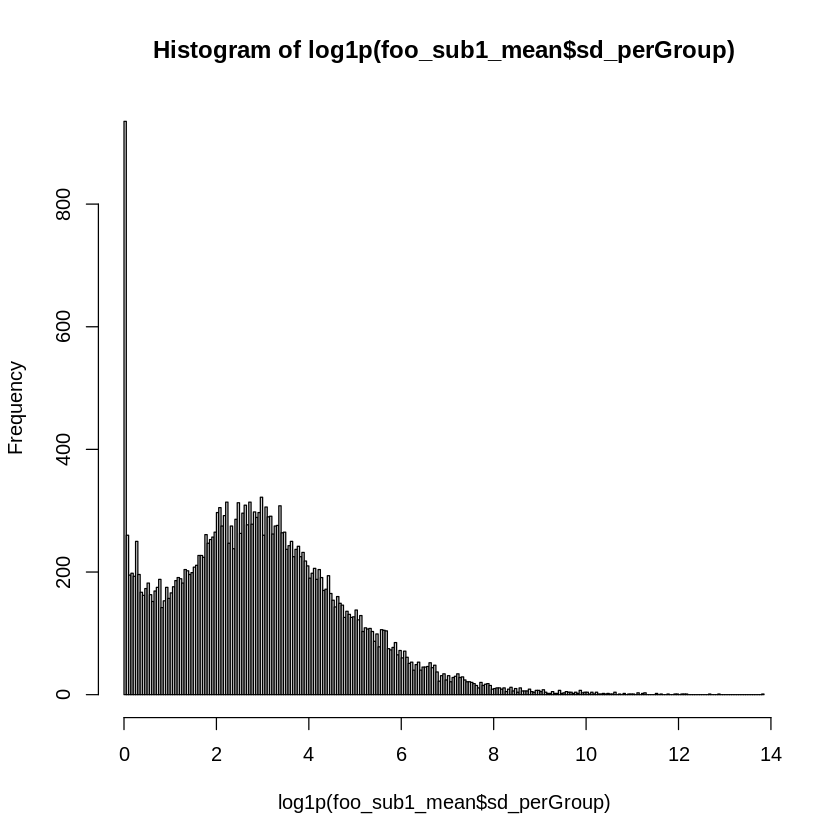

png 
  2

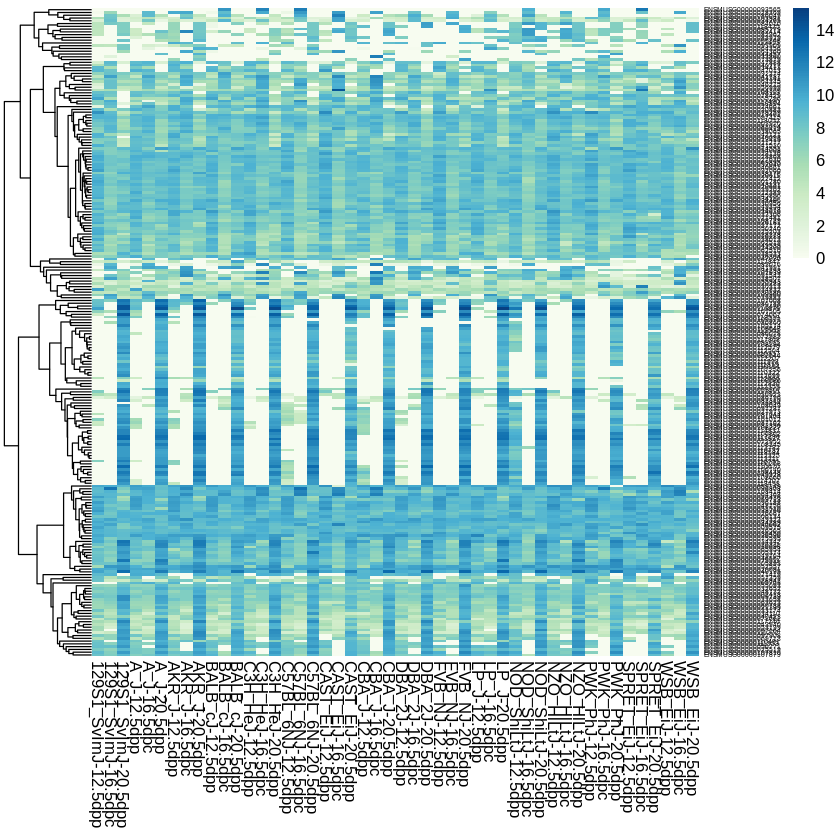

In [185]:

##NEXT IS THE TOP 15% VARIANT miRNA plot on the means. Then the subset more useful miRNA plot
library(pheatmap)

foo_sub_1 <- as.data.frame.matrix(foo_sub_1) #convert from matrix to data frame
## use for eg foo$`hPGC_M_Wk9_n1` <- foo$`hPGC-M-Wk9_2` if only want one biol replicate

colnames(foo_sub_1)

head(foo_sub_1[ , grepl( "^129S1_SvImJ-12.5dpp" , names( foo_sub_1 ) ) ])
foo_sub1_mean = data.frame(matrix(NA, nrow = nrow(foo_sub_1), ncol = 0))
row.names(foo_sub1_mean) <- row.names(foo_sub_1)
for (sample in samplenames) {
foo_sub1_mean[sample] <- apply(foo_sub_1[ , grepl(paste0( "^",sample) , names( foo_sub_1 ) ) ], 1, mean)
}
head(foo_sub1_mean) 

foo_sub1_mean$sd_perGroup <- apply(foo_sub1_mean,1,sd)
hist(log1p(foo_sub1_mean$sd_perGroup),breaks = 200)


nrow(foo_sub1_mean)
3959
foo_sub1_mean_top15sd <- foo_sub1_mean[foo_sub1_mean$sd_perGroup>3959,1:48]
head(foo_sub1_mean_top15sd)
foo_sub1_mean_top15sd$ID<-rownames(foo_sub1_mean_top15sd)
head(foo_sub1_mean_top15sd)



save_pheatmap_pdf <- function(x, filename, width=15, height=25) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    pdf(filename, width=width, height=height,paper="special")
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

savePheatmap <- pheatmap(log1p(foo_sub1_mean_top15sd[,1:48]),width=30000,height=50000, border_color = NA,show_rownames = T, cluster_cols = F, labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 1,fontsize_row = 4, color = hmcol)
save_pheatmap_pdf(savePheatmap,"InitialPheatMap.pdf")

png 
  2

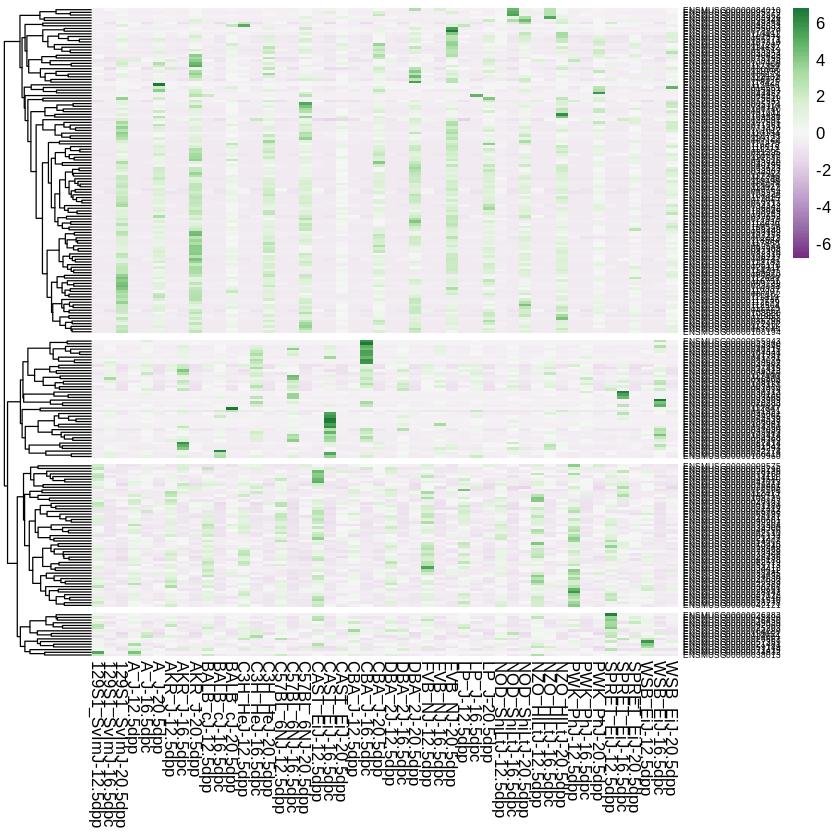

In [186]:
##for z-score
myCol = colorRampPalette(brewer.pal(9,"PRGn"))(100)

savePheatmapZScore <- pheatmap(foo_sub1_mean_top15sd[,1:48], border_color = NA,show_rownames = T,scale = "row",labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 4,fontsize_row = 5, cluster_cols = F, color = myCol)
save_pheatmap_pdf(savePheatmapZScore,"InitialPheatMap_zScore.pdf")